# ** Business Understanding **
This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.The company mainly sells unique all-occasion gifts. Many customers of the company are wholesalers.

[Data Source](https://archive.ics.uci.edu/dataset/352/online+retail)

In [147]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from scipy import stats

## ** Load Data**

In [49]:
df = pd.read_excel('data/Online Retail.xlsx')


## ** Data Understanding: **
- glimpse of the data(head, tail)
- shape(dimensions)
- columns
- information
- data type
- duplicates
- outliers
- null values
- descriptive stats (quantitative and qualitative)

## ** Glimpse of the Data **

In [50]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [51]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


## ** Dimensions, Columns & Datatypes **

In [52]:
rows, columns = df.shape
output = f"Records: {rows} and Features: {columns}"
print(output)

Records: 541909 and Features: 8


In [53]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [54]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

## ** Info, Duplicates, Null Values **

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [56]:
df.duplicated().sum()

np.int64(5268)

In [57]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [58]:
df.isnull().sum() * 100 / len(df)

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

In [59]:
df = df.dropna(axis=0)

In [60]:
df.isnull().sum() * 100 / len(df)

InvoiceNo      0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
UnitPrice      0.0
CustomerID     0.0
Country        0.0
dtype: float64

In [61]:
df.info()

<class 'pandas.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[us]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 27.9+ MB


#### ** Descriptive Stats (Quantitative and Qualitative) **

In [95]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,406829.000000,406829,406829.000000,406829.000000
mean,12.061303,2011-07-10 16:30:57.879207,3.460471,15287.690570
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,13953.000000
50%,5.000000,2011-07-31 11:48:00,1.950000,15152.000000
75%,12.000000,2011-10-20 13:06:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,248.693370,NaN,69.315162,1713.600303


In [91]:
df.describe(include='object') # qualitative data

/var/folders/0c/1j_h2q_d3cz5xx15_x7nbdyw0000gn/T/ipykernel_29291/3942173830.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object') # qualitative data


,InvoiceNo,StockCode,Description,Country
count,406829,406829,406829,406829
unique,22190,3684,3896,37
top,576339,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,542,2077,2070,361878


## ** Visualizations **

In [66]:
 # pie chart
def plotPieChart(labels, data):
    fig, ax = plt.subplots()
    ax.pie(data, labels=labels)

In [70]:
online_retail_labels  = df['Quantity'].unique()
online_retail_labels

array([     6,      8,      2,     32,      3,      4,     24,     12,
           48,     18,     20,     36,     80,     64,     10,    120,
           96,     23,      5,      1,     -1,     50,     40,    100,
          192,    432,    144,    288,    -12,    -24,     16,      9,
          128,     25,     30,     28,      7,     72,    200,    600,
          480,     -6,     14,     -2,     -4,     -5,     -7,     -3,
           11,     70,    252,     60,    216,    384,     27,    108,
           52,  -9360,     75,    270,     42,    240,     90,    320,
           17,   1824,    204,     69,    -36,   -192,   -144,    160,
         2880,   1400,     19,     39,    -48,    -50,     56,     13,
         1440,     -8,     15,    720,    -20,    156,    324,     41,
          -10,    -72,    -11,    402,    378,    150,    300,     22,
           34,    408,    972,    208,   1008,     26,   1000,    -25,
         1488,    250,   1394,    400,    110,    -14,     37,    -33,
      

In [84]:
Quantity_df = df['Quantity'].value_counts()

In [85]:
Quantity_df = pd.DataFrame(Quantity_df).reset_index()
Quantity_df.columns = ['Quantity','count']

In [86]:
df['Quantity'].value_counts()

Quantity
 1        73314
 12       60033
 2        58003
 6        37688
 4        32183
          ...  
 388          1
 1404         1
 698          1
 80995        1
-80995        1
Name: count, Length: 436, dtype: int64

In [87]:
Quantity_df

,Quantity,count
0,1,73314
1,12,60033
2,2,58003
3,6,37688
4,4,32183
...,...,...
431,388,1
432,1404,1
433,698,1
434,80995,1


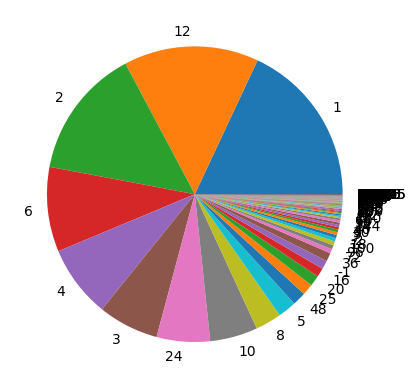

In [88]:
plotPieChart(Quantity_df['Quantity'],Quantity_df['count'] )

## ** Insights **
- The dataset is made up of 541,909 records and  8 features
- The dataset has 5 data types: datetime64[us](1), float64(2), int64(1), object(3), str(1)
- We had 24% of missing values in the dataset the **remedy** was to drop it

** Store Transactions: **
- the store had 406,829. transactions during the period 
- The store had an average of 12.061303 transactions spread out at approx. 15,287.69  customers
- The transaction period is approx. 1 year: from 2010-12-01 08:26:00 to 2011-12-09 12:50:00
- The store has a min of −80,995 representing a high number of cancellations and refunds of orders made
- The store has a max  of 80,995 with std 248.7
- 25% of the clients ordered less than two items
- 50% (median) of the clients ordered arounnd five items
- 75% of the the clients ordered less than twelve items 

In [92]:
df.describe(include='object') # qualitative data

/var/folders/0c/1j_h2q_d3cz5xx15_x7nbdyw0000gn/T/ipykernel_29291/3942173830.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object') # qualitative data


,InvoiceNo,StockCode,Description,Country
count,406829,406829,406829,406829
unique,22190,3684,3896,37
top,576339,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,542,2077,2070,361878


In [108]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,406829.000000,406829,406829.000000,406829.000000
mean,12.061303,2011-07-10 16:30:57.879207,3.460471,15287.690570
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,13953.000000
50%,5.000000,2011-07-31 11:48:00,1.950000,15152.000000
75%,12.000000,2011-10-20 13:06:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,248.693370,NaN,69.315162,1713.600303


In [117]:
Quantity_df.describe()

,Quantity,count
count,436.000000,436.000000
mean,288.800459,933.094037
std,7522.609620,6161.740102
min,-80995.000000,1.000000
25%,-25.250000,1.000000
50%,91.000000,2.000000
75%,436.000000,15.000000
max,80995.000000,73314.000000


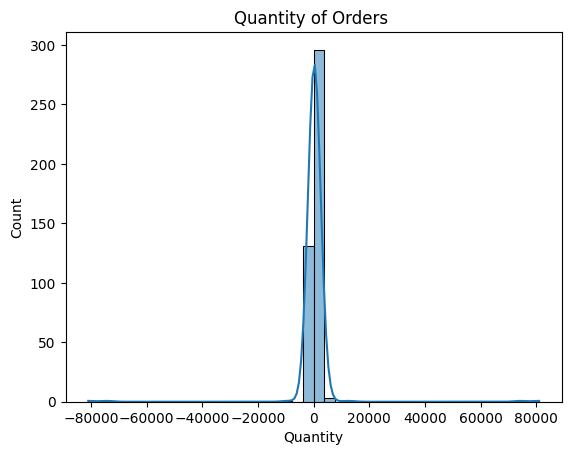

In [118]:
sns.histplot(Quantity_df['Quantity'], kde=True)

plt.title("Quantity of Orders ")
plt.show()

In [179]:
Quantity_df.describe()

,Quantity,count
count,436.000000,436.000000
mean,288.800459,933.094037
std,7522.609620,6161.740102
min,-80995.000000,1.000000
25%,-25.250000,1.000000
50%,91.000000,2.000000
75%,436.000000,15.000000
max,80995.000000,73314.000000


In [184]:
# MoVs
sd = np.std(Quantity_df) 
variance = np.var(Quantity_df)
range_of_values = np.max(Quantity_df) - np.min(Quantity_df) 
output = f"VARIANCE: {variance} || STANDARD DEVIATION: {sd} || RANGE: {range_of_values}"
print(output) 

VARIANCE: 47273690.26556582 || STANDARD DEVIATION: 6875.586539748141 || RANGE: 161990


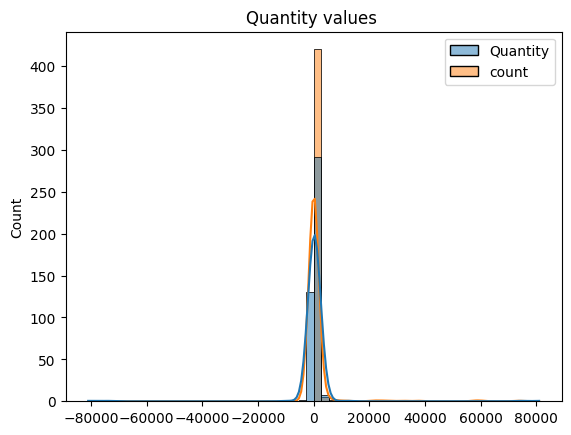

In [187]:
sns.histplot(Quantity_df, kde=True)
plt.title("Quantity values ")
plt.show()

## ** Poisson Distribution **

In [131]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [133]:
df['InvoiceDate'].max() -  df['InvoiceDate'].min() # getting the number of days, this will return an exception

Timedelta('373 days 04:24:00')

Insight:
- it highlights 373 days 04:24:00 days

In [137]:
# aggregate the data per daya
orders_per_day = df.groupby(df['InvoiceDate'].dt.date).size().reset_index()
orders_per_day.columns = ['InvoiceDate', 'Quantity'] # rename columns
orders_per_day

,InvoiceDate,Quantity
0,2010-12-01,1968
1,2010-12-02,2044
2,2010-12-03,1117
3,2010-12-05,2724
4,2010-12-06,1974
...,...,...
300,2011-12-05,3398
301,2011-12-06,2654
302,2011-12-07,2196
303,2011-12-08,2599


#### **Calculate the parameter λ**

In [138]:
lambda_hat = orders_per_day['Quantity'].mean() # lambda hat implies an estimate of lambda 

In [139]:
mean = orders_per_day['Quantity'].mean()
variance = orders_per_day['Quantity'].var()
print(f"Mean: {mean} || Variance: {variance}")
print(f"Are they equal? {mean == variance}")
print(f"Therefore: {'Falls under poisson disrtribution' if mean==variance else 'Further investigation is needed'}")

Mean: 1333.865573770492 || Variance: 381314.6891069888
Are they equal? False
Therefore: Further investigation is needed


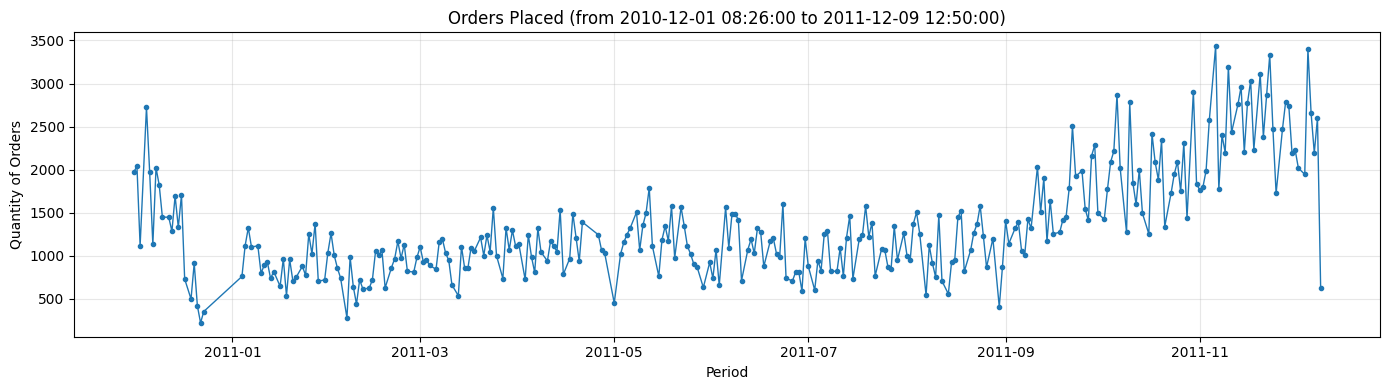

In [144]:
# Plot orders  over time
plt.figure(figsize=(14, 4))
plt.plot(orders_per_day['InvoiceDate'], orders_per_day['Quantity'], marker='o', markersize=3, linewidth=1)
plt.title('Orders Placed (from 2010-12-01 08:26:00 to 2011-12-09 12:50:00)')
plt.xlabel('Period')
plt.ylabel('Quantity of Orders')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Insights:
- Our data does not seem to fit a poisson distribution

** We use the Poisson distribution when: **
- Events occur independently
- One event happening does not influence the next.
- Events occur at a constant average rate λ (lambda).
- Example: 20 customers per hour on average.
- You are counting events within a fixed time/space interval.
- Example: calls per minute, returns per day.
- Events are relatively rare compared to the possible opportunities for them to occur.

# For academic/ learning purposes
#### **Calcluate the probabilities**

Ojective: probability of attaining at least 100 orders per day.  With this at mind three core approached come about:

- **Probability Mass Functoin(PMF)**: **exactly** k=100 
- **Cumulative Density Function(CDF)**: **atmost** k values/ events k <= 100
- **1 - Cumulative Density Function(CDF)**: **atleast** k events k >= 100  **

In [151]:
k  = 10 # 

# attaining exactly 10 orders (PMF) => k=10: 
p_exact = stats.poisson.pmf(k, lambda_hat)

# attaining atmost 10 orders (CDF) => k<=10:
p_atmost = stats.poisson.cdf(k, lambda_hat) 

# attaining atleast 10 orders (CDF) => k >= 10:
p_atleast = 1 - stats.poisson.cdf(k, lambda_hat) 

print(f"Probabilty of getting exaclty {k} outcomes is {p_exact:.6f} ")
print(f"Probabilty of getting atmost {k} outcomes is {p_atmost:.6f} ")
print(f"Probabilty of getting atleast {k} outcomes is {p_atleast:.6f} ")

Probabilty of getting exaclty 10 outcomes is 0.000000 
Probabilty of getting atmost 10 outcomes is 0.000000 
Probabilty of getting atleast 10 outcomes is 1.000000 


In [152]:
k  = 5 # 

# attaining exactly 5 orders (PMF) => k=5: 
p_exact = stats.poisson.pmf(k, lambda_hat)

# attaining atmost 5 orders (CDF) => k<=5:
p_atmost = stats.poisson.cdf(k, lambda_hat) 

# attaining atleast 5 orders (CDF) => k >= 5:
p_atleast = 1 - stats.poisson.cdf(k, lambda_hat) 

print(f"Probabilty of getting exaclty {k} outcomes is {p_exact:.6f} ")
print(f"Probabilty of getting atmost {k} outcomes is {p_atmost:.6f} ")
print(f"Probabilty of getting atleast {k} outcomes is {p_atleast:.6f} ")

Probabilty of getting exaclty 5 outcomes is 0.000000 
Probabilty of getting atmost 5 outcomes is 0.000000 
Probabilty of getting atleast 5 outcomes is 1.000000 


In [ ]:
k  = 2 # 

# attaining exactly 2 orders (PMF) => k=2: 
p_exact = stats.poisson.pmf(k, lambda_hat)

# attaining atmost 2 orders (CDF) => k<=5:
p_atmost = stats.poisson.cdf(k, lambda_hat) 

# attaining atleast 2 orders (CDF) => k >= 2:
p_atleast = 1 - stats.poisson.cdf(k, lambda_hat) 

print(f"Probabilty of getting exaclty {k} outcomes is {p_exact:.6f} ")
print(f"Probabilty of getting atmost {k} outcomes is {p_atmost:.6f} ")
print(f"Probabilty of getting atleast {k} outcomes is {p_atleast:.6f} ")

Probabilty of getting exaclty 2 outcomes is 0.000000 
Probabilty of getting atmost 2 outcomes is 0.000000 
Probabilty of getting atleast 2 outcomes is 1.000000 


In [159]:
k  = 1 # 

# attaining exactly 1 orders (PMF) => k=1: 
p_exact = stats.poisson.pmf(k, lambda_hat)

# attaining atmost 1 orders (CDF) => k<=1:
p_atmost = stats.poisson.cdf(k, lambda_hat) 

# attaining atleast 1 orders (CDF) => k >= 1:
p_atleast = 1 - stats.poisson.cdf(k, lambda_hat) 

print(f"Probabilty of getting exaclty {k} outcomes is {p_exact:.6f} ")
print(f"Probabilty of getting atmost {k} outcomes is {p_atmost:.6f} ")
print(f"Probabilty of getting atleast {k} outcomes is {p_atleast:.6f} ")

Probabilty of getting exaclty 1 outcomes is 0.000000 
Probabilty of getting atmost 1 outcomes is 0.000000 
Probabilty of getting atleast 1 outcomes is 1.000000 


## ** Visualizing the distribution: **

In [161]:
# function to plot a histogram: 

def plotHist(data):
   
    lambda_hat = data.mean()

    # Plot histogram with whole 100 records
    counts, bins, patches = plt.hist(data , bins=5, alpha=0.7, 
                                    color='skyblue', edgecolor='black', 
                                    density=True, label='Actual data')
    # Generate points for the Poisson distribution line
    x = np.arange(data.min() - 2, data.max() + 3, 1) #To Create a SMOOTH LINE for the Theoretical Distribution
    poisson_values = stats.poisson.pmf(x, lambda_hat)

    # Plot Poisson distribution line
    plt.plot(x, poisson_values, 'ro-', linewidth=2, markersize=8, 
            label=f'Poisson distribution (λ={lambda_hat:.2f})', 
            markerfacecolor='red', markeredgecolor='darkred')

    # Add vertical line for the mean
    plt.axvline(lambda_hat, color='green', linestyle='--', 
                linewidth=2, label=f'Mean = {lambda_hat:.2f}')

    # Customize the plot
    plt.xlabel('Number of Orders per Day', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.title('Distribution of Daily Order Volume', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    # Add value labels on the histogram bars
    for i, (bins, patches) in enumerate(zip(bins[:-1], patches)):
        height = patches.get_height()
        if height > 0:
            plt.text(bins + 0.5, height + 0.01, 
                    f'{data.iloc[i]}', 
                    ha='center', fontsize=10)

    # Add text box with statistics
    stats_text = f'Total days: {len(data)}\nMean (λ): {lambda_hat:.2f}\nVariance: {data.var():.2f}'
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

In [171]:
df_1 = calls_per_day['Quantity'].loc[:1] 
df_5 = calls_per_day['Quantity'].loc[:5] 
df_10 = calls_per_day['Quantity'].loc[:10] 
df_20 = calls_per_day['Quantity'].loc[:20] 
df_50 = calls_per_day['Quantity'].loc[:50] 
df_all = calls_per_day['Quantity']

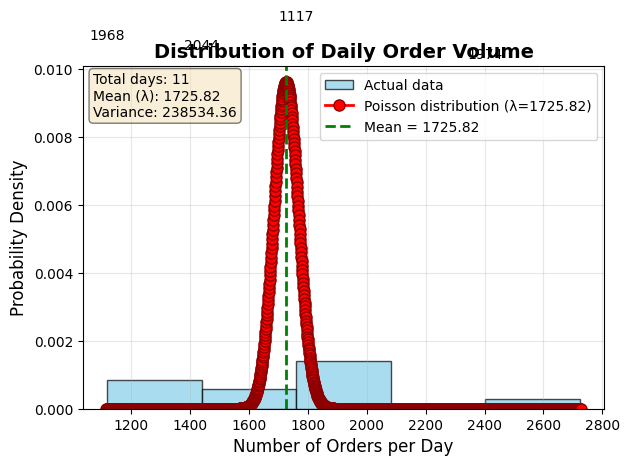

In [166]:
plotHist(df_10)

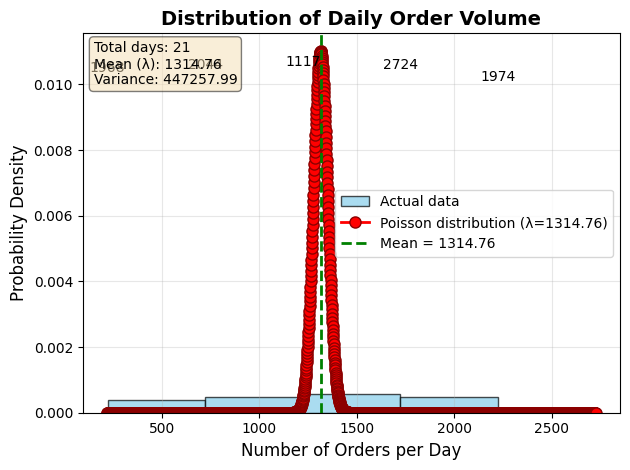

In [168]:
plotHist(df_20)

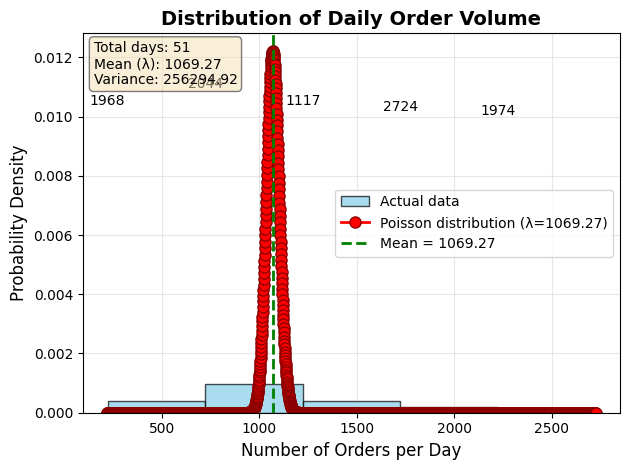

In [ ]:
plotHist(df_50)

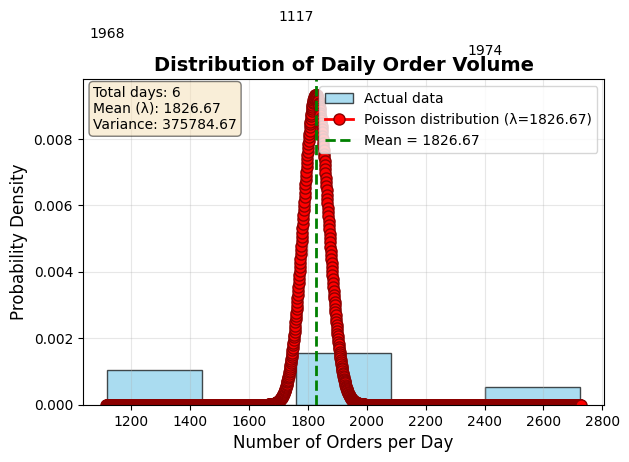

In [172]:
plotHist(df_5)

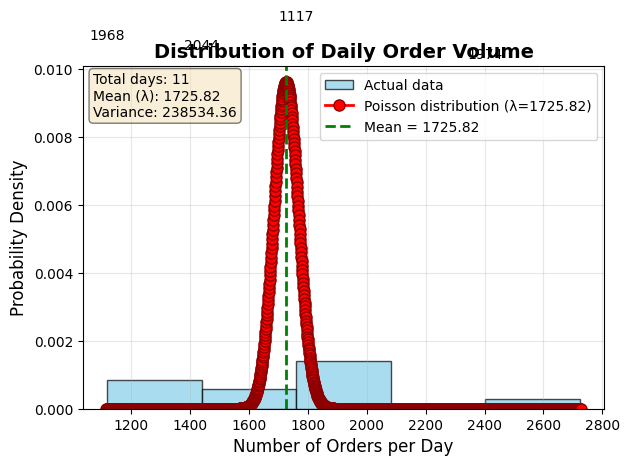

In [173]:
plotHist(df_10)

Text(0.5, 1.0, 'Q-Q Plot against Poisson')

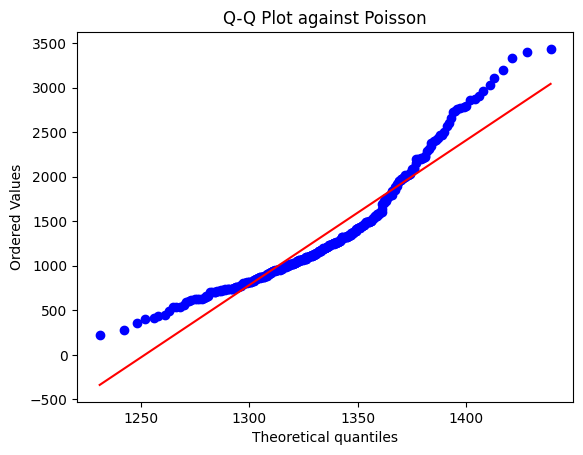

In [174]:
stats.probplot(orders_per_day['Quantity'], dist="poisson", sparams=(lambda_hat,), plot=plt)
plt.title('Q-Q Plot against Poisson')

## ** Insights **
 - The dataset does not fit poisson distribution hence the visualizations
 - Good lesson learnt is to understand the kind of data ( discrete or continous) and apply the distribution that fits the data  including visualizations
